In [1]:
import pandas as pd

df = pd.read_csv('PS1_Dataset.csv')

df.head(5)

,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  object 
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  object 
 4   vehicle_number                298450 non-null  object 
 5   vehicle_type                  298450 non-null  object 
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  object 
 8   offence_code                  298450 non-null  object 
 9   created_datetime              298450 non-null  object 
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  object 
 12  device_id                     298450 non-nul

In [3]:
print("Before", df.shape)

# These columns are completely empty (0 non-null), so they carry zero information.
dead_columns = ['description', 'closed_datetime', 'action_taken_timestamp']

# drop() removes columns. axis=1 means "columns" (axis=0 would mean rows)
df = df.drop(columns=dead_columns)
print("After", df.shape)

Before (298450, 24)
After (298450, 21)


In [4]:
# Sometimes the same violation gets recorded twice by mistake.
# duplicated() checks if any 'id' appears more than once.
print("Duplicate IDs:", df['id'].duplicated().sum())

Duplicate IDs: 0


In [5]:
# pd.to_datetime converts the text "2023-11-20 00:28:46+00" into a real date-time object
df['created_datetime'] = pd.to_datetime(df['created_datetime'],format='mixed')

# Check it worked — dtype should now say "datetime64" instead of "object"
print(df['created_datetime'].dtype)

# Bonus: now we can ask time questions! What's the earliest and latest violation?
print("First violation:", df['created_datetime'].min())
print("Last violation: ", df['created_datetime'].max())

datetime64[ns, UTC]
First violation: 2023-11-09 19:11:46+00:00
Last violation:  2024-04-08 17:30:46+00:00


In [6]:
# Convert from world time (UTC) to Indian time (IST)
# 'Asia/Kolkata' is the official timezone name for all of India
df['created_datetime'] = df['created_datetime'].dt.tz_convert('Asia/Kolkata')

# Check — times should now end in +05:30
print(df['created_datetime'].min())
print(df['created_datetime'].max())

2023-11-10 00:41:46+05:30
2024-04-08 23:00:46+05:30


In [7]:
# Which police station areas have the most violations?
df['police_station'].value_counts().head(10)

police_station
Upparpet             34468
Shivajinagar         28044
Malleshwaram         22200
HAL Old Airport      20819
City Market          17646
Vijayanagara         14652
Rajajinagar          10998
Kodigehalli          10916
Magadi Road           8558
Jeevanbheemanagar     6736
Name: count, dtype: int64

In [8]:
# What kind of vehicles are the biggest offenders?

df['vehicle_type'].value_counts()

vehicle_type
SCOOTER                94856
CAR                    88870
MOTOR CYCLE            40811
PASSENGER AUTO         37813
MAXI-CAB               11372
LGV                     8255
GOODS AUTO              2934
MOPED                   2199
PRIVATE BUS             1633
VAN                     1466
TEMPO                   1368
BUS (BMTC/KSRTC)        1281
HGV                     1144
LORRY/GOODS VEHICLE     1122
JEEP                     913
OTHERS                   895
TOURIST BUS              379
SCHOOL VEHICLE           378
TANKER                   260
FACTORY BUS              238
MINI LORRY               199
TRACTOR                   64
Name: count, dtype: int64

In [9]:
# Which hour of the day is worst? (This is why we fixed the timezone!)

# .dt.hour pulls out just the hour (0 to 23) from each timestamp
# We save it as a new column because we'll reuse it a lot later
df['hour'] = df['created_datetime'].dt.hour

df['hour'].value_counts().sort_index()

hour
0      5815
1     11098
2     16261
3     21565
4     23513
5     22193
6     19838
7     19445
8     25790
9     26996
10    32580
11    32176
12    19689
13    11546
14     5634
15     1224
16      583
17      377
18      150
19       27
20       42
21      148
22      725
23     1035
Name: count, dtype: int64

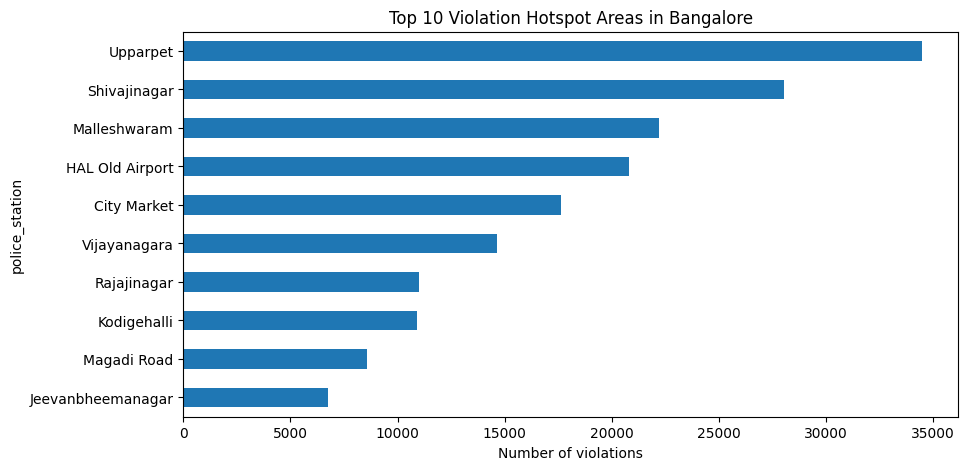

In [10]:
import matplotlib.pyplot as plt   # plt = our drawing pen

top10 = df['police_station'].value_counts().head(10)

plt.figure(figsize=(10, 5))               # canvas size in inches (width, height)
top10.plot(kind='barh')                   # barh = horizontal bars (easier to read names)
plt.title("Top 10 Violation Hotspot Areas in Bangalore")
plt.xlabel("Number of violations")
plt.gca().invert_yaxis()                  # put the biggest bar on top
plt.show()

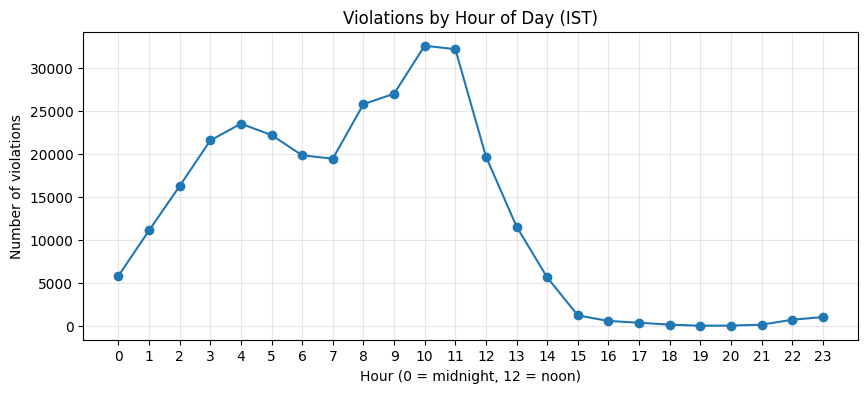

In [11]:
hourly = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
hourly.plot(kind='line', marker='o')      # a line with dots at each hour
plt.title("Violations by Hour of Day (IST)")
plt.xlabel("Hour (0 = midnight, 12 = noon)")
plt.ylabel("Number of violations")
plt.xticks(range(0, 24))                  # show every hour on the x-axis
plt.grid(True, alpha=0.3)                 # faint gridlines, alpha = transparency
plt.show()

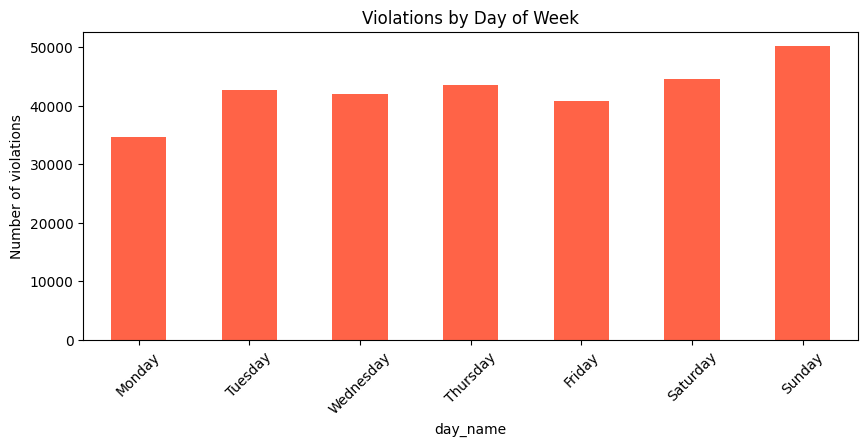

In [12]:
df['day_name'] = df['created_datetime'].dt.day_name()

# Count per day, arranged Monday → Sunday
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df['day_name'].value_counts().reindex(order)

plt.figure(figsize=(10, 4))
daily.plot(kind='bar', color='tomato')
plt.title("Violations by Day of Week")
plt.ylabel("Number of violations")
plt.xticks(rotation=45)                   # tilt labels so they don't overlap
plt.show()

In [13]:
!pip install folium


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# The average of all violation locations = the natural center of our data
center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()
print(center_lat, center_lon) 

12.980801878709848 77.60051221133007


In [19]:

import folium

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)
# Save the map as an HTML file (HTML = the file format of web pages)
m.save('bangalore_map.html')
print("Saved! Open bangalore_map.html in your browser.")

Saved! Open bangalore_map.html in your browser.


In [20]:
from folium.plugins import HeatMap

# A list of [lat, lon] pairs — one per violation
heat_data = df[['latitude', 'longitude']].values

# Dark map style makes the heat colors glow
m = folium.Map(location=[center_lat, center_lon], zoom_start=11,
               tiles='CartoDB dark_matter')

HeatMap(heat_data, radius=8, blur=6).add_to(m)

m.save('bangalore_heatmap.html')
print("Saved! Open bangalore_heatmap.html in your browser.")

Saved! Open bangalore_heatmap.html in your browser.


In [21]:
%pip install scikit-learn

import numpy as np
from sklearn.cluster import DBSCAN

# 1) Take a random sample of 60,000 violations
#    random_state=42 means "shuffle the same way every time" so results are repeatable
sample = df.sample(60000, random_state=42)

# 2) GPS is in degrees, but our circle is in meters. Conversion trick:
#    Earth's radius ≈ 6,371,000 meters. Converting degrees to "radians"
#    lets a math formula (haversine) measure real distances on a round Earth.
coords = np.radians(sample[['latitude', 'longitude']].values)

# 3) 150 meters, expressed in radians:
eps_in_radians = 150 / 6371000

# 4) Run DBSCAN:
db = DBSCAN(
    eps=eps_in_radians,     # circle size = 150 m
    min_samples=100,        # need 100+ violations to count as a hotspot
    metric='haversine',     # measure distance on Earth's curve, not flat paper
    algorithm='ball_tree'   # a fast way to find neighbors
).fit(coords)

# 5) Each point gets a group number. -1 means "noise / lonely point"
sample['cluster'] = db.labels_

n_hotspots = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
noise = (sample['cluster'] == -1).sum()
print("Hotspots found:", n_hotspots)
print("Noise points  :", noise, "out of", len(sample))


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Hotspots found: 71
Noise points  : 16310 out of 60000


In [22]:
# Keep only points that belong to some hotspot (drop the -1 noise)
clustered = sample[sample['cluster'] != -1]

# For each hotspot: where is it (average lat/lon) and how big is it (count)?
hotspots = clustered.groupby('cluster').agg(
    lat=('latitude', 'mean'),
    lon=('longitude', 'mean'),
    violations=('id', 'count')
).sort_values('violations', ascending=False)

hotspots.head(15)

,lat,lon,violations
cluster,,,
9,12.972127,77.577427,12141
0,12.981983,77.608040,5170
10,12.933373,77.690157,2083
2,13.010288,77.553361,2068
5,12.999228,77.549993,1773
14,12.974186,77.547604,1560
16,13.071046,77.587939,1112
29,13.185302,77.680010,898
11,12.998191,77.570826,883


In [23]:
# Pull the date part out of the timestamp (just the day, no time)
df['date'] = df['created_datetime'].dt.date

# Count violations for every (station, date, hour) combination.
# size() = "how many rows in each group" — the count becomes our answer column
agg = (
    df.groupby(['police_station', 'date', 'hour'])
      .size()
      .reset_index(name='violations')   # turn the result back into a normal table
)

print(agg.shape)
agg.head(10)

(45029, 4)


,police_station,date,hour,violations
0,Adugodi,2023-11-10,6,2
1,Adugodi,2023-11-10,17,1
2,Adugodi,2023-11-11,1,3
3,Adugodi,2023-11-11,2,1
4,Adugodi,2023-11-11,4,1
5,Adugodi,2023-11-11,13,2
6,Adugodi,2023-11-11,14,5
7,Adugodi,2023-11-11,15,1
8,Adugodi,2023-11-12,4,1
9,Adugodi,2023-11-12,6,8


In [24]:
import itertools   # a tool for generating combinations

stations = df['police_station'].dropna().unique()   # all station names
dates    = pd.date_range(df['date'].min(), df['date'].max()).date  # every calendar day
hours    = range(24)

# Every possible (station, date, hour) combination — the complete empty scoreboard
full_grid = pd.DataFrame(
    itertools.product(stations, dates, hours),
    columns=['police_station', 'date', 'hour']
)

print("Full grid size:", full_grid.shape)

# Merge: place our real counts onto the grid.
# how='left' = keep every grid slot; slots with no match get NaN (empty)
data = full_grid.merge(agg, on=['police_station', 'date', 'hour'], how='left')

# Those empty slots ARE our zeros — say it explicitly:
data['violations'] = data['violations'].fillna(0).astype(int)

print("Zero rows:", (data['violations'] == 0).sum(), "of", len(data))
data.head()

Full grid size: (195696, 3)
Zero rows: 150667 of 195696


,police_station,date,hour,violations
0,Madiwala,2023-11-10,0,0
1,Madiwala,2023-11-10,1,0
2,Madiwala,2023-11-10,2,0
3,Madiwala,2023-11-10,3,1
4,Madiwala,2023-11-10,4,0


In [26]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,...,data_sent_to_scita,junction_name,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp,hour,day_name,date
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 05:58:46+05:30,2023-11-28 04:48:04.582978+00,...,True,No Junction,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00,5,Monday,2023-11-20
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,"[""NO PARKING""]",[113],2023-11-25 04:16:46+05:30,2023-11-24 23:00:24.115257+00,...,False,No Junction,NaN,NaN,NaN,NaN,NaN,4,Saturday,2023-11-25
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 05:57:46+05:30,2023-11-28 04:47:02.33776+00,...,True,No Junction,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00,5,Monday,2023-11-20
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 12:17:46+05:30,2023-11-18 04:46:57.216868+00,...,True,No Junction,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00,12,Thursday,2023-11-16
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 10:26:46+05:30,2023-11-28 02:44:50.46737+00,...,True,BTP044 - Sagar Theatre Junction,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00,10,Wednesday,2023-11-22


In [27]:
# Make sure 'date' is a proper datetime so we can unpack it
data['date'] = pd.to_datetime(data['date'])

# Clue 1: day of week as a number (Monday=0, Tuesday=1, ... Sunday=6)
data['day_of_week'] = data['date'].dt.dayofweek

# Clue 2: is it a weekend? (1 = yes, 0 = no)
# isin([5,6]) checks if the day is Saturday(5) or Sunday(6)
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

# Clue 3: month (maybe some months are busier — festival season etc.)
data['month'] = data['date'].dt.month

data.head()

,police_station,date,hour,violations,day_of_week,is_weekend,month
0,Madiwala,2023-11-10,0,0,4,0,11
1,Madiwala,2023-11-10,1,0,4,0,11
2,Madiwala,2023-11-10,2,0,4,0,11
3,Madiwala,2023-11-10,3,1,4,0,11
4,Madiwala,2023-11-10,4,0,4,0,11


In [28]:
# Average violations per hour-slot for each station — its "busyness score"
station_avg = data.groupby('police_station')['violations'].mean()

# Map: every row gets its station's busyness score as a feature
data['station_avg'] = data['police_station'].map(station_avg)

data.head()

,police_station,date,hour,violations,day_of_week,is_weekend,month,station_avg
0,Madiwala,2023-11-10,0,0,4,0,11,0.431291
1,Madiwala,2023-11-10,1,0,4,0,11,0.431291
2,Madiwala,2023-11-10,2,0,4,0,11,0.431291
3,Madiwala,2023-11-10,3,1,4,0,11,0.431291
4,Madiwala,2023-11-10,4,0,4,0,11,0.431291


In [29]:
# Sort by time, just to be tidy
data = data.sort_values('date').reset_index(drop=True)

# Cutoff: last 3 weeks = exam, everything before = study material
cutoff = data['date'].max() - pd.Timedelta(days=21)

train = data[data['date'] <= cutoff]
test  = data[data['date'] >  cutoff]

print("Train:", train.shape, "| up to", train['date'].max().date())
print("Test :", test.shape,  "| from",  test['date'].min().date())

Train: (168480, 8) | up to 2024-03-18
Test : (27216, 8) | from 2024-03-19


In [30]:
features = ['hour', 'day_of_week', 'is_weekend', 'month', 'station_avg']

X_train = train[features]
y_train = train['violations']

X_test = test[features]
y_test = test['violations']

In [31]:
from sklearn.ensemble import RandomForestRegressor

# Regressor = predicts a NUMBER (violation count).
# (Classifier would predict a CATEGORY like spam/not-spam — not our case.)
model = RandomForestRegressor(
    n_estimators=100,   # 100 trees in our forest
    random_state=42,    # same randomness every run → reproducible results
    n_jobs=-1           # use all CPU cores → faster training
)

# .fit() = "study this" — here's where learning happens
model.fit(X_train, y_train)

print("Training done!")

Training done!


In [32]:
# .predict() = answer the exam questions (test features), WITHOUT seeing answers
predictions = model.predict(X_test)

# Peek: model's guesses vs reality, side by side
comparison = test[['police_station', 'date', 'hour']].copy()
comparison['actual'] = y_test.values
comparison['predicted'] = predictions.round(1)

comparison.sample(10, random_state=1)   # 10 random exam questions

,police_station,date,hour,actual,predicted
176123,Yelahanka,2024-03-24,13,0,1.1
193095,Hennuru,2024-04-06,11,12,1.2
179598,Chikkajala,2024-03-27,5,3,2.3
187565,Hebbala,2024-04-02,12,0,3.3
192725,V.V.Puram (C.Pet),2024-04-06,21,0,1.1
188408,Banaswadi,2024-04-03,22,0,0.0
174503,Bellandur,2024-03-23,19,0,0.0
176754,Chikkabanavara,2024-03-25,8,0,0.0
176993,Vijayanagara,2024-03-25,23,0,0.0
189952,Mico Layout,2024-04-04,1,0,0.0


In [33]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("MAE:", round(mae, 3), "violations per station-hour")

# Context to judge it: what if we lazily predicted the average every time?
baseline = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print("Lazy baseline MAE:", round(baseline, 3))

MAE: 1.706 violations per station-hour
Lazy baseline MAE: 2.327


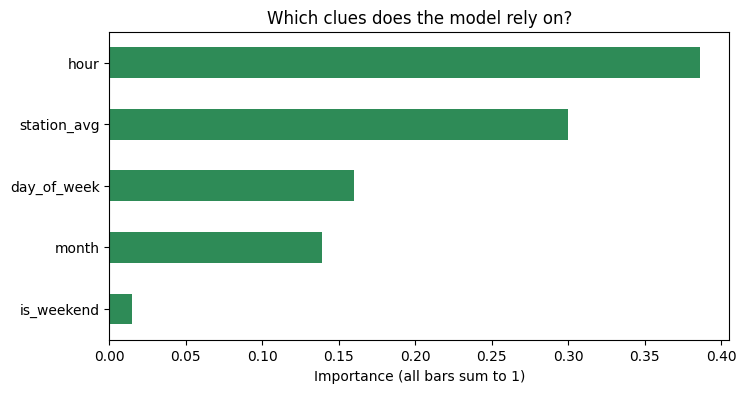

In [34]:
importance = pd.Series(model.feature_importances_, index=features).sort_values()

importance.plot(kind='barh', figsize=(8, 4), color='seagreen')
plt.title("Which clues does the model rely on?")
plt.xlabel("Importance (all bars sum to 1)")
plt.show()

In [35]:
def forecast_station(station_name, target_date):
    """Predict hour-by-hour violations for one station on one date."""

    # Safety check: does this station exist in our data?
    if station_name not in station_avg.index:
        print("Unknown station:", station_name)
        return None

    target = pd.to_datetime(target_date)

    # Manufacture 24 rows — one per hour of the target day
    future = pd.DataFrame({
        'hour': range(24),
        'day_of_week': target.dayofweek,          # same for all 24 rows
        'is_weekend': int(target.dayofweek >= 5),
        'month': target.month,
        'station_avg': station_avg[station_name]  # the station's busyness score
    })

    # Ask the model. Negative counts are impossible → clip them to 0
    future['predicted'] = model.predict(future[features]).clip(0).round(1)

    return future

# Try it!
result = forecast_station('Upparpet', '2024-04-09')
result.head(10)

,hour,day_of_week,is_weekend,month,station_avg,predicted
0,0,1,0,4,9.511038,9.1
1,1,1,0,4,9.511038,19.6
2,2,1,0,4,9.511038,20.5
3,3,1,0,4,9.511038,13.4
4,4,1,0,4,9.511038,20.4
5,5,1,0,4,9.511038,24.6
6,6,1,0,4,9.511038,10.6
7,7,1,0,4,9.511038,19.7
8,8,1,0,4,9.511038,13.8
9,9,1,0,4,9.511038,24.5


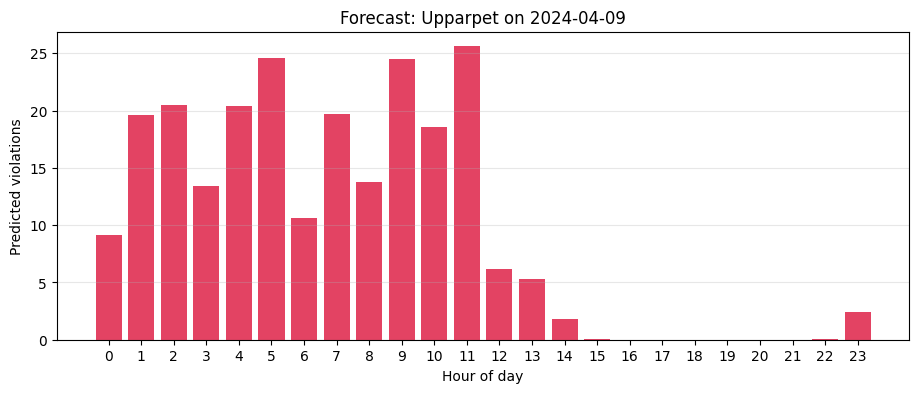

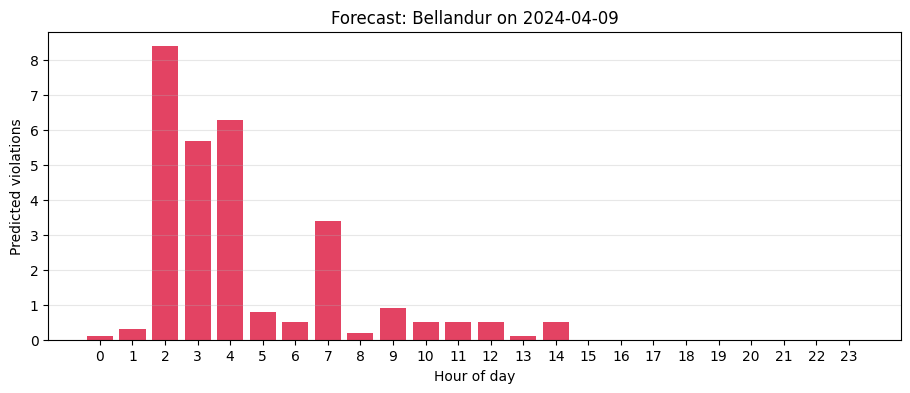

In [36]:
def plot_forecast(station_name, target_date):
    fc = forecast_station(station_name, target_date)
    if fc is None:
        return

    plt.figure(figsize=(11, 4))
    plt.bar(fc['hour'], fc['predicted'], color='crimson', alpha=0.8)
    plt.title(f"Forecast: {station_name} on {target_date}")
    plt.xlabel("Hour of day")
    plt.ylabel("Predicted violations")
    plt.xticks(range(24))
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_forecast('Upparpet', '2024-04-09')
plot_forecast('Bellandur', '2024-04-09')

In [37]:
%pip install joblib

import joblib

# 1) Save the trained model (joblib is made for saving ML models)
joblib.dump(model, 'violation_model.pkl')

# 2) Save the hotspot table and station scores (CSV is fine for tables)
hotspots.to_csv('hotspots.csv')
station_avg.to_csv('station_avg.csv')

# 3) Save a slimmed-down copy of the data for the dashboard's charts & heatmap.
#    (Only the columns the dashboard needs — keeps the file small and fast)
df[['latitude', 'longitude', 'police_station', 'vehicle_type',
    'hour', 'day_name', 'date']].to_csv('dashboard_data.csv', index=False)

print("Suitcase packed! 4 files saved.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Suitcase packed! 4 files saved.
